<div
     style="padding: 20px;
            color: white;
            font-size: 250%;
            text-align: center;
            display: fill;
            border-radius: 5px;
            background-color: #2a2a9fab;
            overflow: hidden;
            font-weight: 700;
            border: 5px solid #bebe0d;"
     >
Using NYT API to Determine Cincinnati Popularity
</div>

**Aims**: 

* Check the popularity of Cincinnati in the NY Times between 2010 and 2019. 
* Use the number of published articles in the NY Times as the proxy for popularity. 
* Use matplotlib to draw a time series plot (a sample listed below) for article counts in each year.

In [ ]:
#Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import time
import requests

#Step 2: Set up API
api_key = "[INSERT_API_KEY]"
base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

#Step 3: Define range and build dictionary
years = range(2010, 2020)
article_counts = {}
request_delay_seconds = 15

#Step 4: Loop through each year
for year in years:   # for each year
    params = {        # with these parameters below
        "q": "Cincinnati",
        "begin_date": f"{year}0101",
        "end_date": f"{year}1231",
        "api-key": api_key
    }

    response = requests.get(base_url, params=params, timeout=30)

    # If the API rate limit is reached, wait and try the same year again once.
    if response.status_code == 429:
        time.sleep(60)
        response = requests.get(base_url, params=params, timeout=30)

    response_json = response.json()

    if response.status_code == 200 and "response" in response_json:
        response_details = response_json["response"]
        metadata = response_details.get("metadata", response_details.get("meta", {}))
        article_counts[year] = metadata.get("hits")
        print(f"{year}: {article_counts[year]} articles")
    else:
        article_counts[year] = None
        message = response_json.get("fault", {}).get("faultstring", response.text)
        print(f"{year}: Rate limit or no data (saved as None). {message}")

    time.sleep(request_delay_seconds)

df_counts = pd.DataFrame(list(article_counts.items()), columns=["Year", "Article Count"])

df_counts

2010: 1018 articles
2011: 914 articles
2012: 993 articles
2013: 829 articles
2014: 821 articles
2015: 817 articles
2016: 736 articles
2017: 556 articles
2018: 522 articles
2019: 462 articles


,Year,Article Count
0,2010,1018
1,2011,914
2,2012,993
3,2013,829
4,2014,821
5,2015,817
6,2016,736
7,2017,556
8,2018,522
9,2019,462


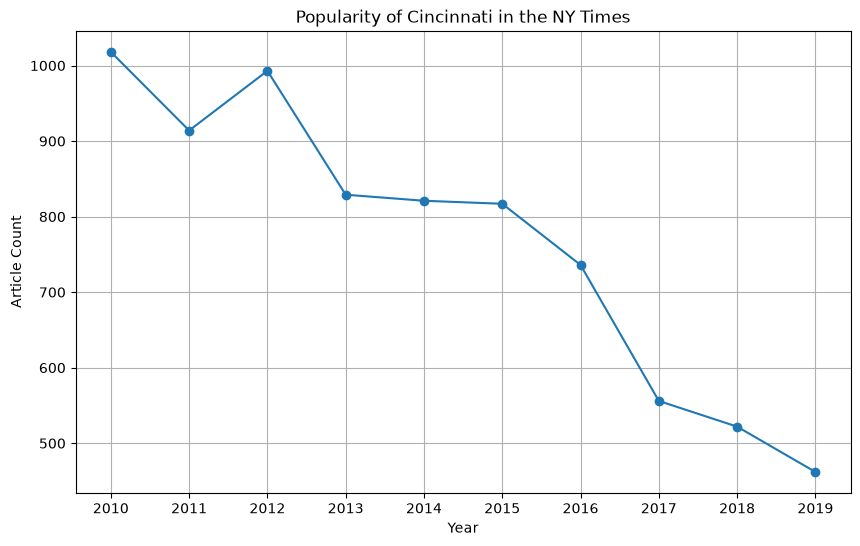

In [4]:
# Step 5: Plot the yearly article counts
plt.figure(figsize=(10, 6))
plt.plot(df_counts["Year"], df_counts["Article Count"], marker="o", linestyle="-")
plt.title("Popularity of Cincinnati in the NY Times")
plt.xlabel("Year")
plt.ylabel("Article Count")
plt.xticks(df_counts["Year"])
plt.grid(True)
plt.show()